In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import fsps
from jax import jit
from tqdm import tqdm
from astropy import constants as const
tiny_number = 1e-70

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 100     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 10**-4.3477116)  # constant metallicity (Z=0.02)

ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

ssp_data.ssp_flux.shape


sp = fsps.StellarPopulation(zcontinuous=3, sfh=3, add_neb_emission=False, add_neb_continuum=False)


In [2]:
sp.set_tabular_sfh(age = np.asarray(t), sfr = np.asarray(sfr_bimodal), Z=zh)
wave, spec_fsps_dustfree= sp.get_spectrum(tage=13.8) 

In [3]:
diffdust = 0.2
diffdust_index = -0.7
young_dust = 0.1
young_dust_index = -1


In [4]:


sp.params['dust1'] = young_dust
sp.params['dust2'] = diffdust
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index

sp.params['add_dust_emission'] = False
sp.params['dust_type'] = 4

wave, spec_fsps_diffuse = sp.get_spectrum(tage=13.8) 
print('FSPS with \ndust1:', sp.params['dust1'], '\ndust2:', sp.params['dust2'], '\ndust1_index:', sp.params['dust1_index'], '\ndust_index:', sp.params['dust_index'])


sp.params['add_dust_emission'] = True
sp.params['duste_umin'] = 1.0
sp.params['duste_qpah'] = 3.5
sp.params['duste_gamma'] = 1

wave, spec_fsps_hot_dust_emi = sp.get_spectrum(tage=13.8)


sp.params['add_dust_emission'] = True
sp.params['duste_umin'] = 1.0
sp.params['duste_qpah'] = 3.5
sp.params['duste_gamma'] = 0

wave, spec_fsps_cold_dust_emi = sp.get_spectrum(tage=13.8)


wave, spec_fsps_cold_dust_emi_reverse= sp.get_spectrum(tage=0.001) 

FSPS with 
dust1: 0.1 
dust2: 0.2 
dust1_index: -1.0 
dust_index: -0.7


In [14]:
import pickle as pkl

with open('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/fsps_dust_spectra_gen1.pkl', 'wb') as f:
    pkl.dump({'wave': wave,
              'spec_fsps_dustfree': spec_fsps_dustfree,
              'spec_fsps_diffuse': spec_fsps_diffuse,
              'spec_fsps_hot_dust_emi': spec_fsps_hot_dust_emi,
              'spec_fsps_cold_dust_emi': spec_fsps_cold_dust_emi}, f)

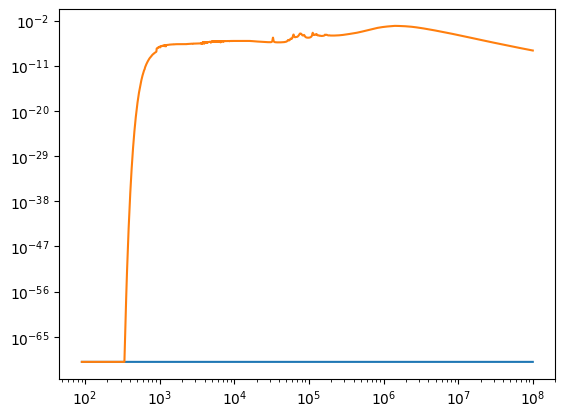

In [5]:
plt.loglog(wave, spec_fsps_cold_dust_emi_reverse, label='Cold Dust Emission only at 1 Myr')
plt.loglog(wave, spec_fsps_cold_dust_emi, label=' at 13.8 Gyr')


In [6]:
diff_params = {'tau_pow': young_dust,
                'alpha': -young_dust_index, 'tau_kc': 0.0, 'dust_index': 0.0,
                'diffuse_params': {'tau_kc': diffdust, 'dust_index': diffdust_index}}

dust_params = {'tau_pow': young_dust,
                'alpha': -young_dust_index, 'tau_kc': 0.0, 'dust_index': 0.0,
                'diffuse_params': {'tau_kc': diffdust, 'dust_index': diffdust_index}}

emi_params = {'duste_qpah': 0.5, 
              'duste_umin': 1.0, 
              'duste_gamma': 0.01}
#-------------------------------
# CSP SPECTRUM WITH DUST
#-------------------------------
csp_dusty = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal, 'zh': zh}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = True, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 
                                'laws': ['powerlaw']}, verbose = True)

theta = jnp.array(csp_dusty.theta_init.at[csp_dusty.tau_pow_idx].set(young_dust))
theta = jnp.array(theta.at[csp_dusty.alpha_idx].set(young_dust_index))
theta = jnp.array(theta.at[csp_dusty.diffuse_dust_index_idx].set(diffdust_index))
theta = jnp.array(theta.at[csp_dusty.diffuse_tau_kc_idx].set(diffdust))

spec_dust = csp_dusty.get_spectrum(theta)

theta = jnp.array(csp_dusty.theta_init.at[csp_dusty.tau_pow_idx].set(0))
theta = jnp.array(theta.at[csp_dusty.alpha_idx].set(0))
theta = jnp.array(theta.at[csp_dusty.diffuse_dust_index_idx].set(diffdust_index))
theta = jnp.array(theta.at[csp_dusty.diffuse_tau_kc_idx].set(diffdust))

spec_diffuse = csp_dusty.get_spectrum(theta)

#-------------------------------
# CSP SPECTRUM WITHOUT DUST
#-------------------------------

theta = jnp.array(csp_dusty.theta_init.at[csp_dusty.tau_pow_idx].set(0))
theta = jnp.array(theta.at[csp_dusty.alpha_idx].set(0))
theta = jnp.array(theta.at[csp_dusty.diffuse_dust_index_idx].set(0))
theta = jnp.array(theta.at[csp_dusty.diffuse_tau_kc_idx].set(0))

spec_dustfree = csp_dusty.get_spectrum(theta)


Using combined (binwise + diffuse) dust attenuation.
Initializing Dust attenuation model...
Initializing DiffuseDust model...
Dust initialization complete.
Parameters registered: ['lookback_time', 'sfh', 'zh', 'tau_pow', 'alpha', 'diffuse_tau_kc', 'diffuse_dust_index']


Get spectrum with dust attenuation only and no nebular emission
dict_keys(['sfh_times', 'sfh', 'theta_init', 'alpha_idx', 'diffuse_dust_index_idx', 'diffuse_tau_kc_idx', 'sfh_idx', 'tau_pow_idx', 'zh_idx'])


In [7]:
csp = csp_dusty

(1e-10, 1e-05)

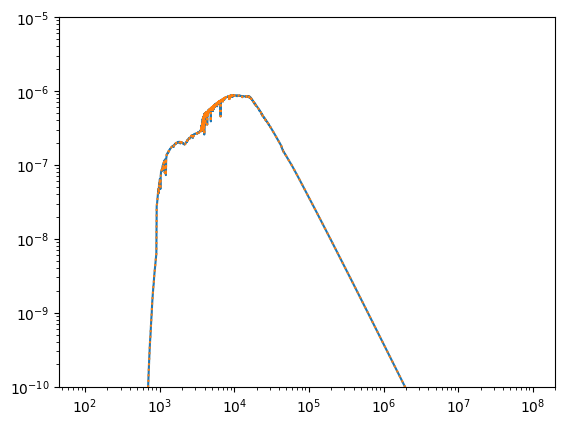

In [8]:
plt.loglog(csp.wave, spec_fsps_diffuse)
plt.loglog(csp.wave, spec_dust, ls = ':')
plt.ylim(1e-10, 1e-5)


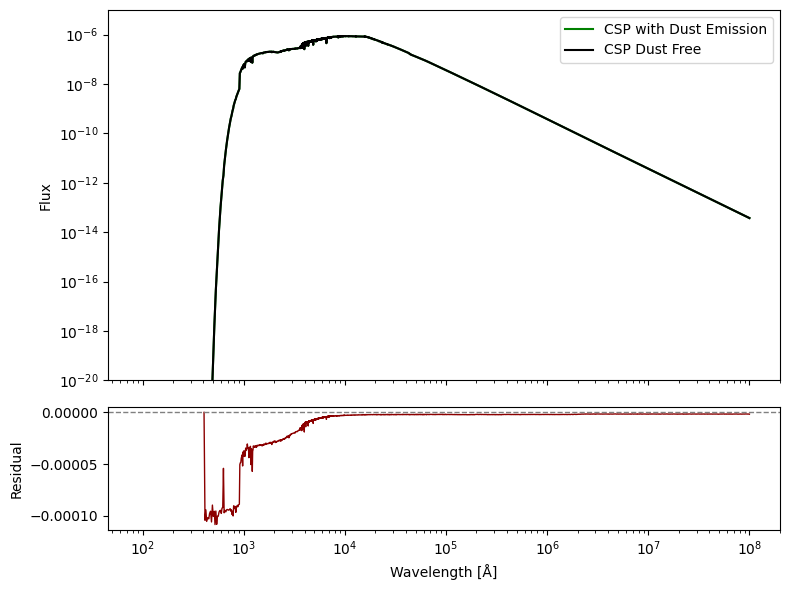

In [9]:

residuals = (spec_dust - spec_fsps_diffuse) / spec_fsps_diffuse

# Create 2-panel figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

# Top panel: SEDs
ax1.loglog(csp.wave, spec_dust, color='green', label='CSP with Dust Emission')
ax1.loglog(csp.wave, spec_fsps_diffuse, color='black', label='CSP Dust Free')
ax1.legend()
ax1.set_ylabel("Flux")
ax1.set_ylim(1e-20, 1e-5)

# Bottom panel: normalized residuals
ax2.plot(csp.wave, residuals, color='darkred', linewidth=1)
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
ax2.set_xscale('log')
ax2.set_xlabel("Wavelength [Å]")
ax2.set_ylabel("Residual")
#ax2.set_ylim(-1, 1)

plt.tight_layout()
plt.show()

In [10]:
from ceridwen.dust.DustEmission import DustEmission

In [11]:
emi = DustEmission(spec_lambda=csp.wave, dust_file='/Users/amanda/Prospector/fsps')
emi.load_dust_emission()

specdust_hot, mdust, tduste_hot = emi.compute_dust_emission(spec_diffuse=spec_dust, spec_dustfree=spec_dustfree,
                                                        spec_lambda=csp.wave, diffuse_curve=spec_diffuse/spec_dustfree,
                                                        duste_qpah=3.5, duste_umin=1.0, duste_gamma=1.)

specdust_cold, mdust, tduste_cold = emi.compute_dust_emission(spec_diffuse=spec_dust, spec_dustfree=spec_dustfree,
                                                        spec_lambda=csp.wave, diffuse_curve=spec_diffuse/spec_dustfree,
                                                        duste_qpah=3.5, duste_umin=1.0, duste_gamma=0.)

nu shape: (5994,)
lbold: ()
lboln: ()
dustem2dustem (5994, 7, 44)
gamma  ()
dumin (5994,)
dumax (5994,)
mduste shape AFTER    MAX (5994,)
mduste shape: (5994,)
labs shape: ()
nu shape: (5994,)
mduste shape: (5994,)
nu shape: (5994,)
lbold: ()
lboln: ()
dustem2dustem (5994, 7, 44)
gamma  ()
dumin (5994,)
dumax (5994,)
mduste shape AFTER    MAX (5994,)
mduste shape: (5994,)
labs shape: ()
nu shape: (5994,)
mduste shape: (5994,)


In [12]:
emi.dustem2_dustem.shape

(5994, 7, 44)

-6.4768756e-05


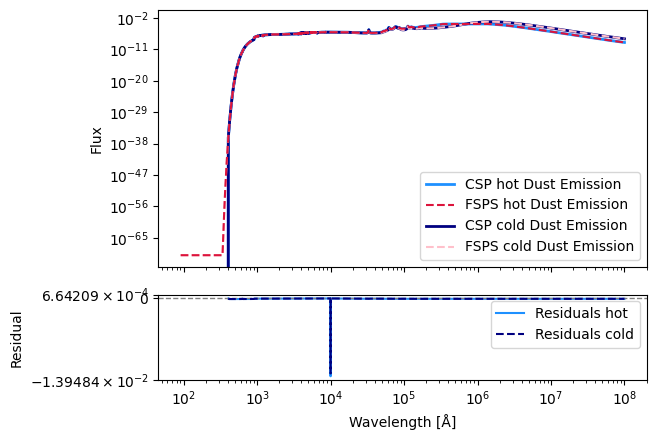

In [13]:

# Compute normalized residuals
residuals = (specdust_hot - spec_fsps_hot_dust_emi) / spec_fsps_hot_dust_emi

# Create figure with two vertically stacked subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20/3, 4.5), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

# Top panel: spectra
ax1.loglog(csp.wave, specdust_hot, color='dodgerblue', lw = 2, label='CSP hot Dust Emission')
ax1.loglog(csp.wave, spec_fsps_hot_dust_emi, ls = 'dashed', color='crimson', label='FSPS hot Dust Emission', zorder = 100)


ax1.loglog(csp.wave, specdust_cold, color='navy', lw = 2, label='CSP cold Dust Emission')
ax1.loglog(csp.wave, spec_fsps_cold_dust_emi, ls = 'dashed', color='pink', label='FSPS cold Dust Emission')
#ax1.set_ylim(1e-8, 1e-2)
#ax1.set_xlim(8*1e3, 1e7)
ax1.set_ylabel("Flux")
ax1.legend()

# Bottom panel: normalized residuals
ax2.plot(csp.wave, residuals, color='dodgerblue', label='Residuals hot')
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)


residuals = (specdust_cold - spec_fsps_cold_dust_emi) / spec_fsps_cold_dust_emi
ax2.plot(csp.wave, residuals, color='navy', ls = 'dashed', label='Residuals cold')
ax2.legend()
ax2.set_yscale('symlog')
ax2.set_ylabel("Residual")
ax2.set_xlabel("Wavelength [Å]")
#ax2.set_ylim(-0.5*1e-3, 0.5*1e-3)

plt.tight_layout()
print(residuals[-1])

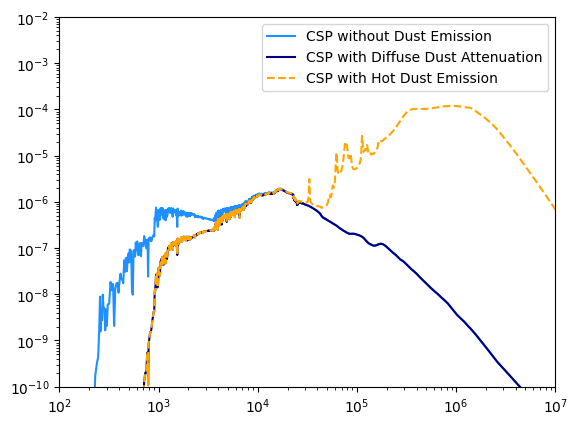

In [ ]:
plt.loglog(csp.wave, spec_dustfree, color='dodgerblue', label='CSP without Dust Emission')
plt.loglog(csp.wave, spec_diffuse, color='navy', label='CSP with Diffuse Dust Attenuation')
plt.loglog(csp.wave, specdust_hot, color='orange', ls = '--', label='CSP with Hot Dust Emission')
plt.legend()
plt.ylim(1e-10, 1e-2)
plt.xlim(1e2, 1e7)

plt.savefig('young_low_dust_attenuation_emission.png')